# Lap-One Gate Detection Tuning

Use this notebook to tune the grayscale gate detector on saved `flight_frames` before flying. It mirrors the current `lap_one_evan.py` behavior: choose the rightmost bright contour, with an option to include edge-touching contours and draw every detected gate in green.

In [46]:
from pathlib import Path
import math
import json
import re
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'myassignement').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'myassignement'))

from cv_detection import DIST, K, detect_gate, find_corners_polydp, order_corners

FRAMES_ROOT = ROOT / 'myassignement' / 'flight_frames'
SETTINGS_PATH = ROOT / 'myassignement' / 'lap_one_detection_settings.json'
DEFAULT_SETTINGS = {
    'threshold': 230,
    'min_area': 120,
    'median_ksize': 3,
    'close_short': 5,
    'close_long': 9,
    'dilate_extra': 3,
    'border_pad': 0,
    'close_coverage': 1.0,
    'include_border': True,
    'all_green': True,
    'folder': '20260524_140130',
    'frame': 40,
    'view': 'filled',
}

def load_settings():
    settings = dict(DEFAULT_SETTINGS)
    if SETTINGS_PATH.exists():
        try:
            settings.update(json.loads(SETTINGS_PATH.read_text(encoding='utf-8')))
            print('loaded settings:', SETTINGS_PATH)
        except Exception as exc:
            print('could not load settings:', exc)
    return settings

settings = load_settings()
print('frames root:', FRAMES_ROOT)

loaded settings: c:\Users\ayoub\Code\Aerial_Hardware\myassignement\lap_one_detection_settings.json
frames root: c:\Users\ayoub\Code\Aerial_Hardware\myassignement\flight_frames


In [47]:
def contour_center_x(contour):
    moments = cv2.moments(contour)
    if abs(moments['m00']) > 1e-6:
        return moments['m10'] / moments['m00']
    x, _, w, _ = cv2.boundingRect(contour)
    return x + 0.5 * w


def choose_rightmost_detection(result, include_border=True):
    candidates = list(result.get('accepted') or [])
    if include_border:
        candidates.extend(result.get('rejected_border') or [])
        if result.get('commit_to_pass') is not None:
            candidates.append(result['commit_to_pass'])
    if not candidates:
        return result

    rightmost = max(candidates, key=contour_center_x)
    corners, approx = find_corners_polydp(rightmost)

    tuned = dict(result)
    tuned['selected'] = rightmost
    tuned['smoothed'] = approx
    tuned['curvature'] = None
    tuned['quad_pix'] = None
    tuned['quad_norm'] = None

    if corners is None:
        tuned['status'] = 'no_corners'
        return tuned

    corners = order_corners(corners)
    tuned['quad_pix'] = corners
    tuned['quad_norm'] = cv2.undistortPoints(
        corners.reshape(-1, 1, 2).astype(np.float32), K, DIST
    ).reshape(-1, 2)
    tuned['status'] = 'ok'
    return tuned


def render_tuning_overlay(gray, result, all_green=True):
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    candidates = []
    candidates.extend(result.get('accepted') or [])
    candidates.extend(result.get('rejected_border') or [])
    if result.get('commit_to_pass') is not None:
        candidates.append(result['commit_to_pass'])

    if all_green and candidates:
        cv2.drawContours(vis, candidates, -1, (0, 170, 0), 2)
    elif result.get('accepted'):
        cv2.drawContours(vis, result['accepted'], -1, (0, 120, 0), 1)
    if result.get('rejected_border') and not all_green:
        cv2.drawContours(vis, result['rejected_border'], -1, (0, 0, 255), 2)

    if result.get('selected') is not None:
        cv2.drawContours(vis, [result['selected']], -1, (0, 255, 0), 2)

    if result.get('quad_pix') is not None:
        pts = np.int32(result['quad_pix']).reshape(-1, 1, 2)
        cv2.polylines(vis, [pts], True, (0, 255, 255), 1)
        for x, y in result['quad_pix']:
            cv2.circle(vis, (int(x), int(y)), 4, (0, 255, 255), -1)

    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)


def apply_median(gray, median_ksize=3):
    k = int(median_ksize)
    if k <= 1:
        return gray
    if k % 2 == 0:
        k += 1
    return cv2.medianBlur(gray, k)


def run_detector(gray, threshold=230, min_area=120, border_pad=0, close_coverage=1.0,
                 include_border=True, median_ksize=3, close_short=5, close_long=9,
                 dilate_extra=3):
    gray = apply_median(gray, median_ksize)
    result = detect_gate(
        gray,
        threshold=int(threshold),
        min_area=int(min_area),
        border_pad=int(border_pad),
        close_coverage=float(close_coverage),
        close_short=int(close_short),
        close_long=int(close_long),
        dilate_extra=int(dilate_extra),
        open_size=1,
    )
    return choose_rightmost_detection(result, include_border=include_border)

In [48]:
folders = sorted([p.name for p in FRAMES_ROOT.iterdir() if p.is_dir()])
folders

['20260524_132927',
 '20260524_134149',
 '20260524_135050',
 '20260524_135959',
 '20260524_140130']

In [49]:
# Edit these, then re-run the cell below.
folder_name = '20260524_140130'
start_frame = 31
end_frame = 66

threshold = 230
min_area = 120
median_ksize = 3
close_short = 5
close_long = 9
dilate_extra = 3
open_size = 1
border_pad = 0
close_coverage = 1.0
include_border = True
all_green = True

cols = 4
save_grid = True

In [50]:
# Interactive tuning window
folder_dropdown = widgets.Dropdown(options=folders, value=settings.get('folder', '20260524_140130') if settings.get('folder', '20260524_140130') in folders else folders[0], description='folder')
frame_slider = widgets.IntSlider(value=int(settings.get('frame', 40)), min=0, max=1, step=1, description='frame', continuous_update=False)
threshold_slider = widgets.IntSlider(value=int(settings.get('threshold', 230)), min=120, max=255, step=1, description='threshold', continuous_update=False)
min_area_slider = widgets.IntSlider(value=int(settings.get('min_area', 120)), min=20, max=20000, step=20, description='min_area', continuous_update=False)
median_slider = widgets.SelectionSlider(options=[1, 3, 5, 7, 9], value=int(settings.get('median_ksize', 3)), description='median')
close_short_slider = widgets.IntSlider(value=int(settings.get('close_short', 5)), min=1, max=31, step=2, description='close short', continuous_update=False)
close_long_slider = widgets.IntSlider(value=int(settings.get('close_long', 9)), min=1, max=61, step=2, description='close long', continuous_update=False)
dilate_slider = widgets.IntSlider(value=int(settings.get('dilate_extra', 3)), min=1, max=21, step=2, description='dilate', continuous_update=False)
border_slider = widgets.IntSlider(value=int(settings.get('border_pad', 0)), min=0, max=30, step=1, description='border', continuous_update=False)
coverage_slider = widgets.FloatSlider(value=float(settings.get('close_coverage', 1.0)), min=0.0, max=1.0, step=0.01, description='coverage', continuous_update=False)
include_border_box = widgets.Checkbox(value=bool(settings.get('include_border', True)), description='include border')
all_green_box = widgets.Checkbox(value=bool(settings.get('all_green', True)), description='all green')
view_options = [
    ('overlay', 'overlay'),
        ('filtered grayscale', 'filtered'),
        ('binary threshold mask', 'binary'),
        ('closed rim mask', 'closed'),
        ('closed + filled holes', 'closed_filled'),
]
view_values = [value for _, value in view_options]
view_value = settings.get('view', 'closed_filled')
if view_value not in view_values:
    view_value = 'closed_filled'
view_dropdown = widgets.Dropdown(options=view_options, value=view_value, description='view')
save_button = widgets.Button(description='Save settings', button_style='success', icon='save')
status = widgets.HTML()
save_status = widgets.HTML()
image = widgets.Image(format='png')


def current_settings():
    return {
        'threshold': threshold_slider.value,
        'min_area': min_area_slider.value,
        'median_ksize': median_slider.value,
        'close_short': close_short_slider.value,
        'close_long': close_long_slider.value,
        'dilate_extra': dilate_slider.value,
        'border_pad': border_slider.value,
        'close_coverage': coverage_slider.value,
        'include_border': include_border_box.value,
        'all_green': all_green_box.value,
        'folder': folder_dropdown.value,
        'frame': frame_slider.value,
        'view': view_dropdown.value,
    }


def set_frame_range(*_):
    current_files = sorted((FRAMES_ROOT / folder_dropdown.value).glob('*.jpg'))
    old = frame_slider.value
    frame_slider.max = max(0, len(current_files) - 1)
    frame_slider.value = min(old, frame_slider.max)
    redraw()


def image_bytes(rgb):
    ok, encoded = cv2.imencode('.png', cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    if not ok:
        return b''
    return encoded.tobytes()


def gray_to_rgb(gray):
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)


def redraw(*_):
    current_files = sorted((FRAMES_ROOT / folder_dropdown.value).glob('*.jpg'))
    if not current_files:
        status.value = '<b>No frames found.</b>'
        image.value = b''
        return

    idx = min(frame_slider.value, len(current_files) - 1)
    path = current_files[idx]
    gray_raw = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if gray_raw is None:
        status.value = f'<b>Could not read {path.name}</b>'
        image.value = b''
        return

    gray_filtered = apply_median(gray_raw, median_slider.value)
    result = run_detector(
        gray_raw,
        threshold=threshold_slider.value,
        min_area=min_area_slider.value,
        border_pad=border_slider.value,
        close_coverage=coverage_slider.value,
        include_border=include_border_box.value,
        median_ksize=median_slider.value,
        close_short=close_short_slider.value,
        close_long=close_long_slider.value,
        dilate_extra=dilate_slider.value,
    )

    view = view_dropdown.value
    if view == 'overlay':
        vis = render_tuning_overlay(gray_filtered, result, all_green=all_green_box.value)
    elif view == 'filtered':
        vis = gray_to_rgb(gray_filtered)
    elif view == 'binary':
        vis = gray_to_rgb(result['prep']['raw'])
    elif view == 'closed':
        vis = gray_to_rgb(result['prep']['closed'])
    elif view == 'closed_filled':
        closed_filled = cv2.bitwise_or(result['prep']['closed'], result['prep']['interior'])
        vis = gray_to_rgb(closed_filled)
    else:
        vis = render_tuning_overlay(gray_filtered, result, all_green=all_green_box.value)

    center = ''
    if result.get('quad_pix') is not None:
        cx, cy = np.mean(result['quad_pix'], axis=0)
        center = f' center=({cx:.1f}, {cy:.1f})'
    status.value = (
        f'<b>{folder_dropdown.value}/{path.name}</b> status=<b>{result["status"]}</b>{center} '
        f'accepted={len(result.get("accepted") or [])} '
        f'border={len(result.get("rejected_border") or [])} '
        f'view={view}'
    )
    image.value = image_bytes(vis)


def save_settings(_):
    settings = current_settings()
    settings_path = SETTINGS_PATH
    settings_path.write_text(json.dumps(settings, indent=2), encoding='utf-8')

    controller_path = ROOT / 'myassignement' / 'lap_one_evan.py'
    text = controller_path.read_text(encoding='utf-8')
    replacements = {
        'DETECTION_THRESHOLD': settings['threshold'],
        'DETECTION_MIN_AREA': settings['min_area'],
        'DETECTION_MEDIAN_KSIZE': settings['median_ksize'],
        'DETECTION_CLOSE_SHORT': settings['close_short'],
        'DETECTION_CLOSE_LONG': settings['close_long'],
        'DETECTION_DILATE_EXTRA': settings['dilate_extra'],
        'DETECTION_BORDER_PAD': settings['border_pad'],
    }
    for name, value in replacements.items():
        text = re.sub(rf'^{name} = .+$', f'{name} = {value}', text, flags=re.MULTILINE)
    text = re.sub(r'^DETECTION_CLOSE_COVERAGE = .+$', f'DETECTION_CLOSE_COVERAGE = {settings["close_coverage"]:.2f}', text, flags=re.MULTILINE)
    controller_path.write_text(text, encoding='utf-8')
    save_status.value = f'Saved to <code>{settings_path}</code> and updated <code>{controller_path.name}</code>.'


folder_dropdown.observe(set_frame_range, names='value')
for widget in [
    frame_slider, threshold_slider, min_area_slider, median_slider,
    close_short_slider, close_long_slider, dilate_slider,
    border_slider, coverage_slider, include_border_box, all_green_box, view_dropdown,
]:
    widget.observe(redraw, names='value')
save_button.on_click(save_settings)

set_frame_range()
controls = widgets.VBox([
    widgets.HBox([folder_dropdown, frame_slider, view_dropdown]),
    widgets.HBox([threshold_slider, min_area_slider, median_slider]),
    widgets.HBox([close_short_slider, close_long_slider]),
    widgets.HBox([dilate_slider]),
    widgets.HBox([border_slider, coverage_slider]),
    widgets.HBox([include_border_box, all_green_box, save_button]),
    status,
    save_status,
])
display(controls, image)
redraw()


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01D\x00\x00\x00\xf4\x08\x02\x00\x00\x00l5\xc8P\x00\…

{'ok': 36}
saved: c:\Users\ayoub\Code\Aerial_Hardware\myassignement\flight_frames\20260524_140130\detection_tuning_20260524_140130_031_066.jpg


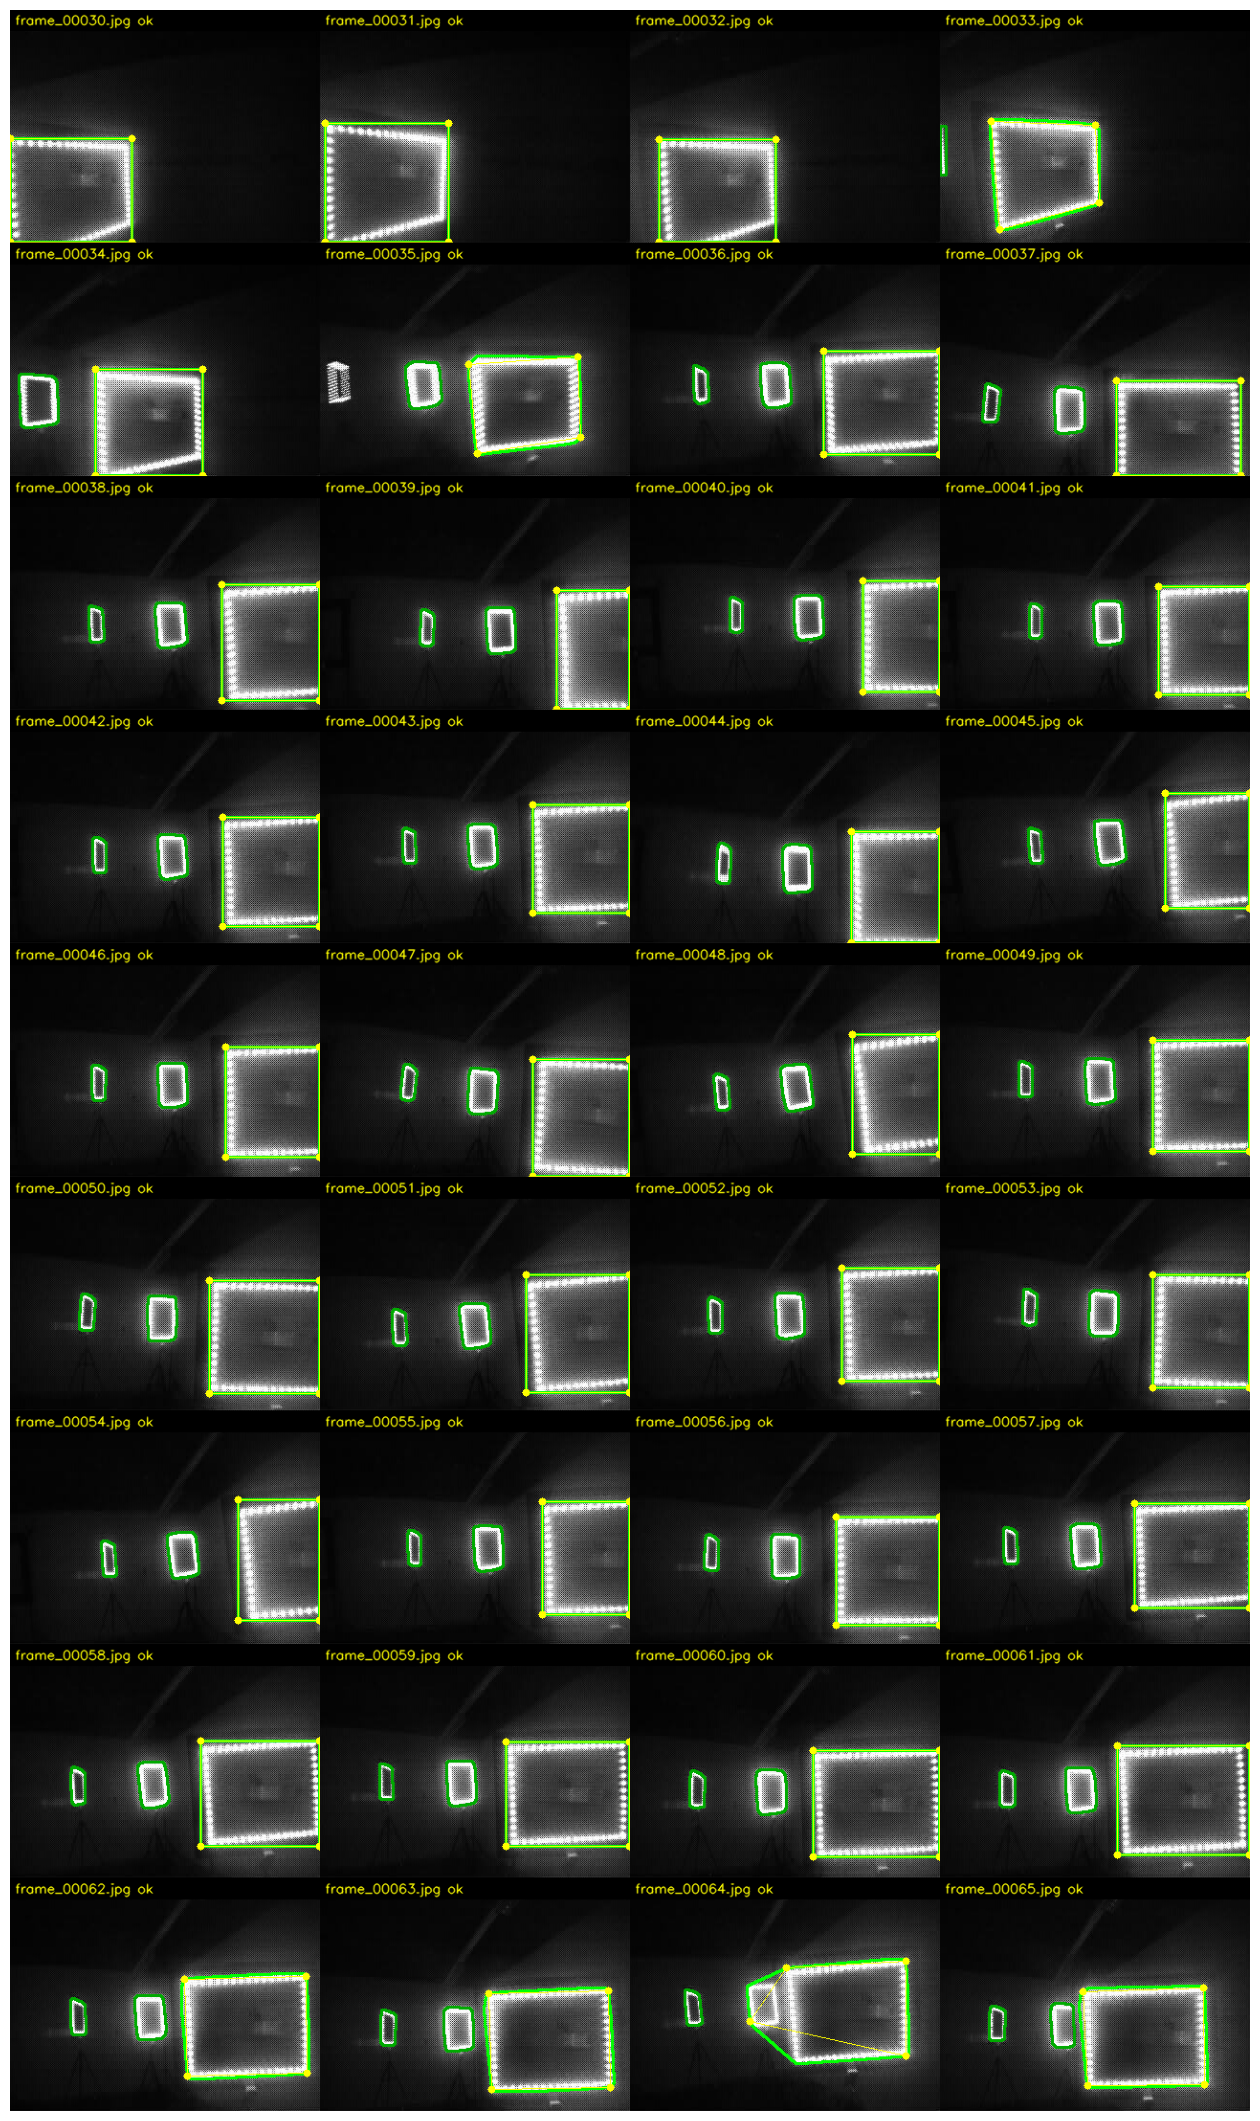

In [51]:
folder = FRAMES_ROOT / folder_name
files = sorted(folder.glob('*.jpg'))
indices = list(range(start_frame, min(end_frame + 1, len(files))))

thumbs = []
counts = {}
for idx in indices:
    path = files[idx]
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    result = run_detector(
        gray,
        threshold=threshold,
        min_area=min_area,
        border_pad=border_pad,
        close_coverage=close_coverage,
        include_border=include_border,
        median_ksize=median_ksize,
        close_short=close_short,
        close_long=close_long,
        dilate_extra=dilate_extra,
    )
    counts[result['status']] = counts.get(result['status'], 0) + 1
    vis = render_tuning_overlay(gray, result, all_green=all_green)

    label = f'{path.name} {result["status"]}'
    vis_bgr = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
    cv2.rectangle(vis_bgr, (0, 0), (vis_bgr.shape[1], 22), (0, 0, 0), -1)
    color = (0, 255, 255) if result['status'] == 'ok' else (180, 180, 180)
    cv2.putText(vis_bgr, label, (5, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    thumbs.append(cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB))

rows = math.ceil(len(thumbs) / cols)
h, w = thumbs[0].shape[:2]
grid = np.zeros((rows * h, cols * w, 3), dtype=np.uint8)
for i, thumb in enumerate(thumbs):
    r, c = divmod(i, cols)
    grid[r*h:(r+1)*h, c*w:(c+1)*w] = thumb

print(counts)
plt.figure(figsize=(16, 4 * rows))
plt.imshow(grid)
plt.axis('off');

if save_grid:
    out = folder / f'detection_tuning_{folder_name}_{start_frame:03d}_{end_frame:03d}.jpg'
    cv2.imwrite(str(out), cv2.cvtColor(grid, cv2.COLOR_RGB2BGR))
    print('saved:', out)

frame_00062.jpg ok
quad_pix: [[182. 106.]
 [309. 103.]
 [310. 204.]
 [185. 207.]]
center_px: [246.5 155. ]


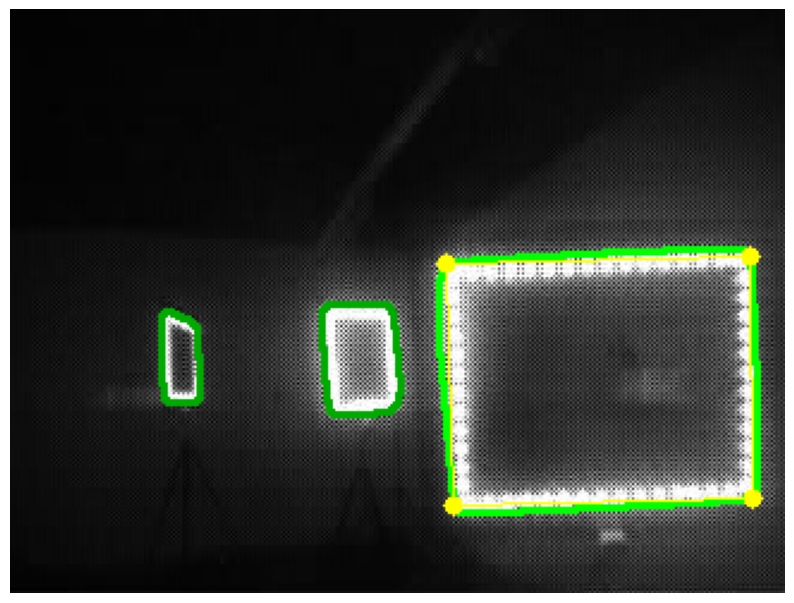

In [52]:
# Single-frame zoom for corner/debug inspection.
frame_index = 63
path = files[frame_index]
gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
result = run_detector(gray, threshold, min_area, border_pad, close_coverage, include_border, median_ksize, close_short, close_long, dilate_extra)
vis = render_tuning_overlay(gray, result, all_green=all_green)

print(path.name, result['status'])
if result.get('quad_pix') is not None:
    print('quad_pix:', np.round(result['quad_pix'], 1))
    print('center_px:', np.round(np.mean(result['quad_pix'], axis=0), 1))

plt.figure(figsize=(10, 8))
plt.imshow(vis)
plt.axis('off');